##Bibliotecas

In [41]:
import re
import random

## Expressões Regulares

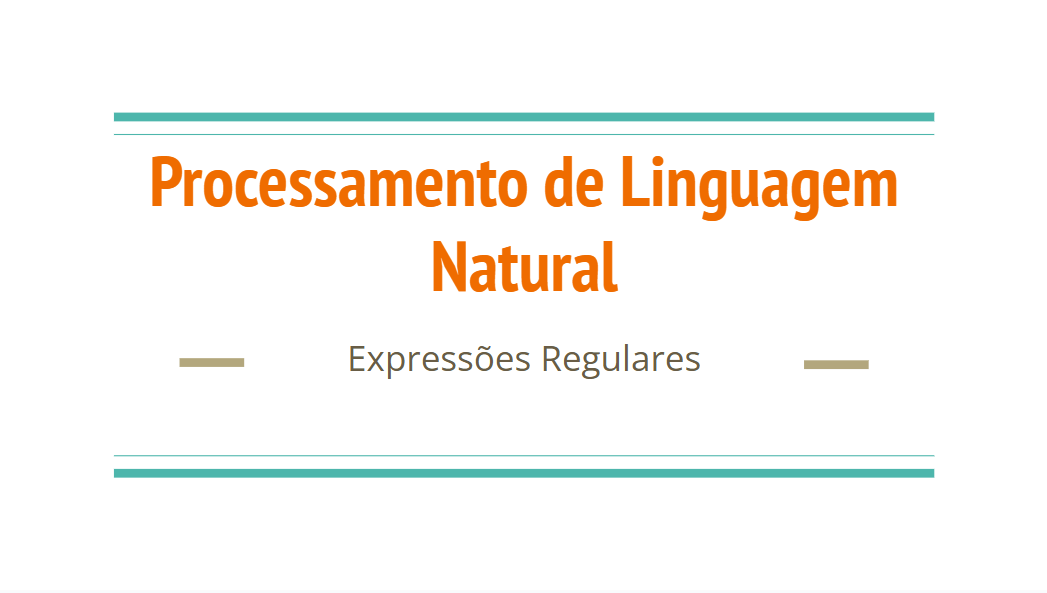

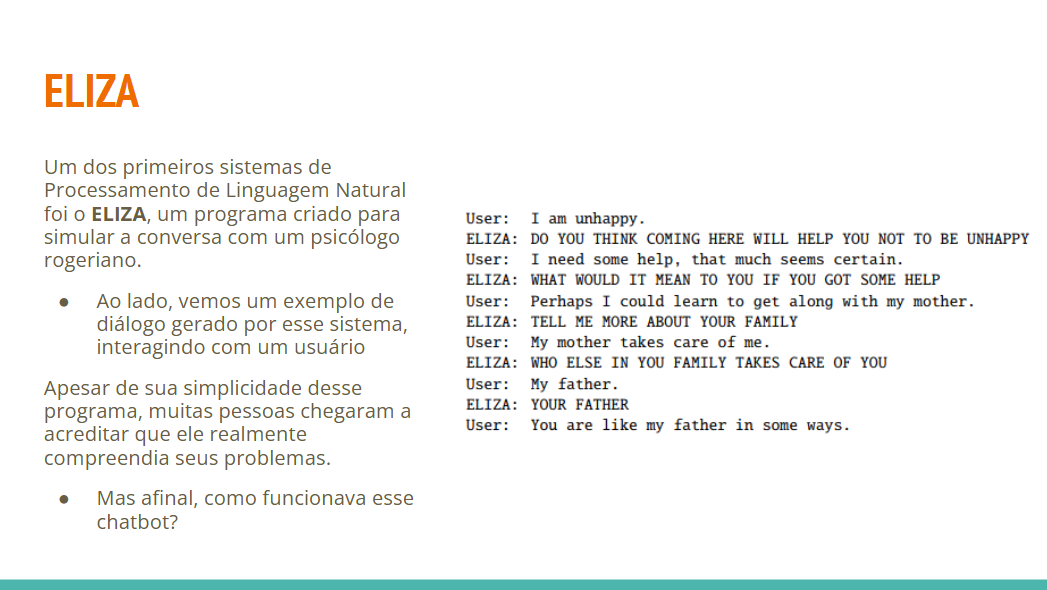

Para conversar com o ELIZA: https://www.masswerk.at/elizabot/

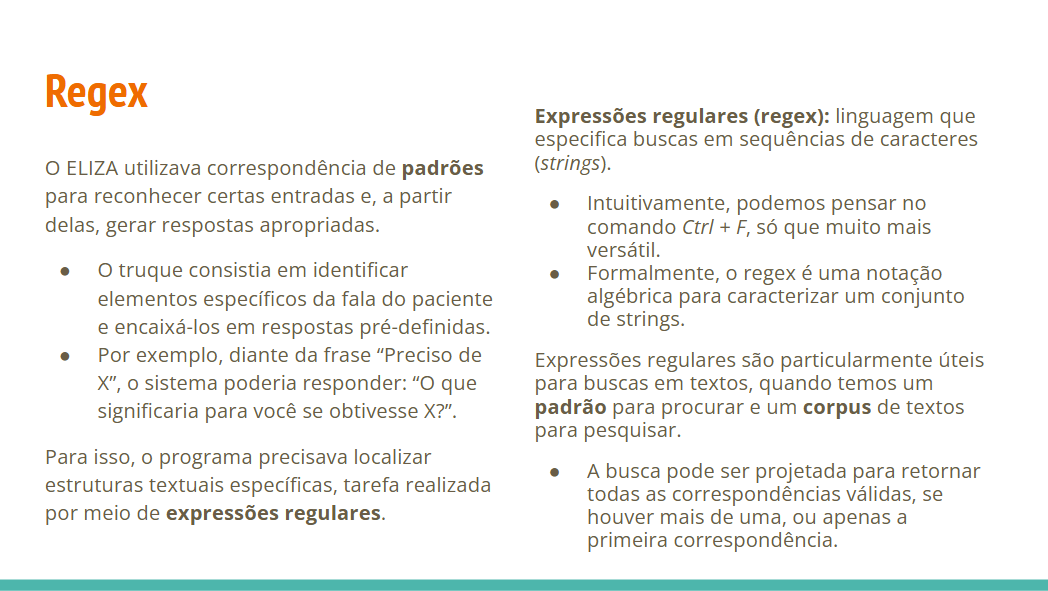

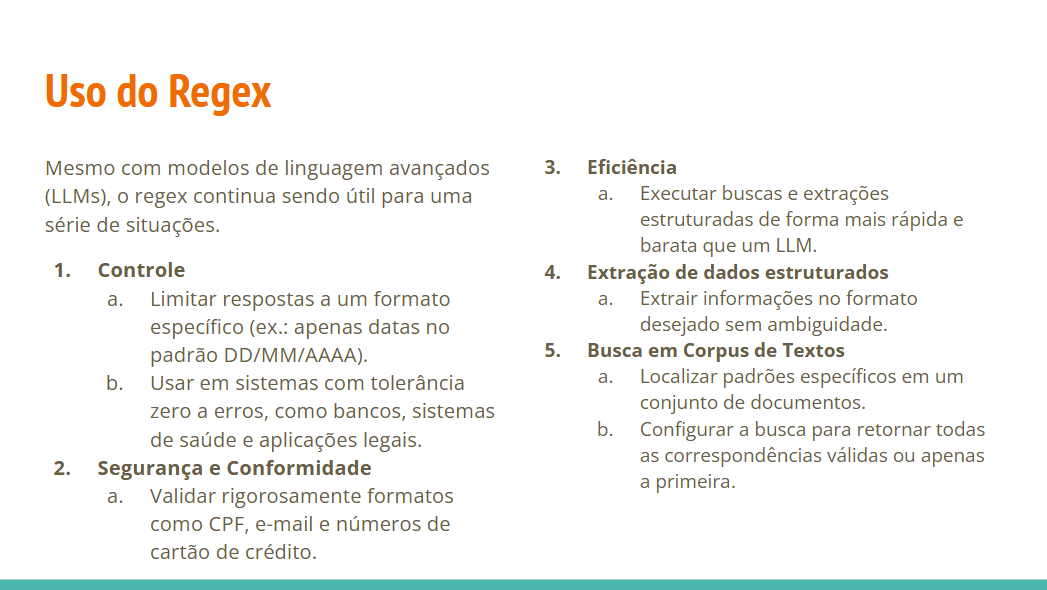

## Busca

Utilizamos expressões regulares para encontrar padrões em textos. Assim, antes de entender como construir essas expressões, precisamos entender como realizar buscas em strings.

In [2]:
# Encontrando o substring 'o'
texto = "O aluno entregou a atividade"
padrao = 'o'
ocorrencias = re.findall(padrao, texto)

print(ocorrencias)

['o', 'o']


Veja que a nossa busca só encontrou uma ocorrência do pronome 'e', quando de fato havia várias.

**Importante:** o regex é **case-sensitive**.

In [3]:
# Outra forma de fazer a busca
texto = "Eu gosto de estudar, mas eu também gosto de descansar."
padrao = re.compile('o')
ocorrencias = padrao.findall(texto)

print(ocorrencias)

['o', 'o', 'o', 'o']


Em python, a busca por padrões pode ser feita de diversas maneiras:

*   **re.search(**padrao, string**):**
  * **O que faz:** Busca a primeira correspondência do padrão em qualquer parte da string.
  * **Quando usar:** Quando você quer saber se o padrão aparece em algum ponto do texto, e só precisa da primeira ocorrência.


*   **re.findall(**padrao, string**):**
  * **O que faz:** Retorna todas as correspondências do padrão na string, como uma lista.
  * **Quando usar:** Quando você precisa extrair todos os trechos que batem com o padrão.

*   **re.match(**padrao, string**):**
  * **O que faz:** Busca uma correspondência apenas no início da string.
  * **Quando usar:** Quando o padrão precisa estar obrigatoriamente no começo do texto.

*   **re.compile(**padrao, string**):**
  * **O que faz:** Compila a expressão regular em um objeto de padrão reutilizável.
  * **Quando usar:** Quando você vai aplicar a mesma regex várias vezes em textos diferentes, para evitar recompilar a expressão e ganhar eficiência.

*   **re.sub(**padrao, substituicao, string**):**
  * **O que faz:** Substitui todas as ocorrências do padrão por um texto especificado.
  * **Quando usar:** Quando é necessário limpar, padronizar ou alterar trechos de texto.

### Aplicação

Este programa solicita que o usuário digite um texto contendo uma **placa de carro no formato Mercosul** — três letras maiúsculas, um número, uma letra e dois números (por exemplo, `ABC1D23`).

Em seguida, ele utiliza expressões regulares para procurar esse padrão dentro do texto informado.

* Se o padrão for encontrado, o programa exibe a placa detectada.

* Caso contrário, informa que nenhuma placa válida foi encontrada.

O **re.search()** é usado para localizar a primeira correspondência do padrão específico na string.

In [4]:
# Padrão para placa Mercosul: 3 letras, 1 número, 1 letra, 2 números
padrao = r"[A-Z]{3}\d[A-Z]\d{2}"

# Entrada do usuário
texto = input("Digite a placa do carro no formato Mercosul (ex.: ABC1D23): ")

# Procura o padrão no texto
m = re.search(padrao, texto)

# Verifica se encontrou e exibe o resultado
if m:
    print(f"Padrão encontrado: {m.group()}")
else:
    print("Nenhuma placa válida encontrada.")

Digite a placa do carro no formato Mercosul (ex.: ABC1D23): AVC1D23
Padrão encontrado: AVC1D23


## Operadores básicos

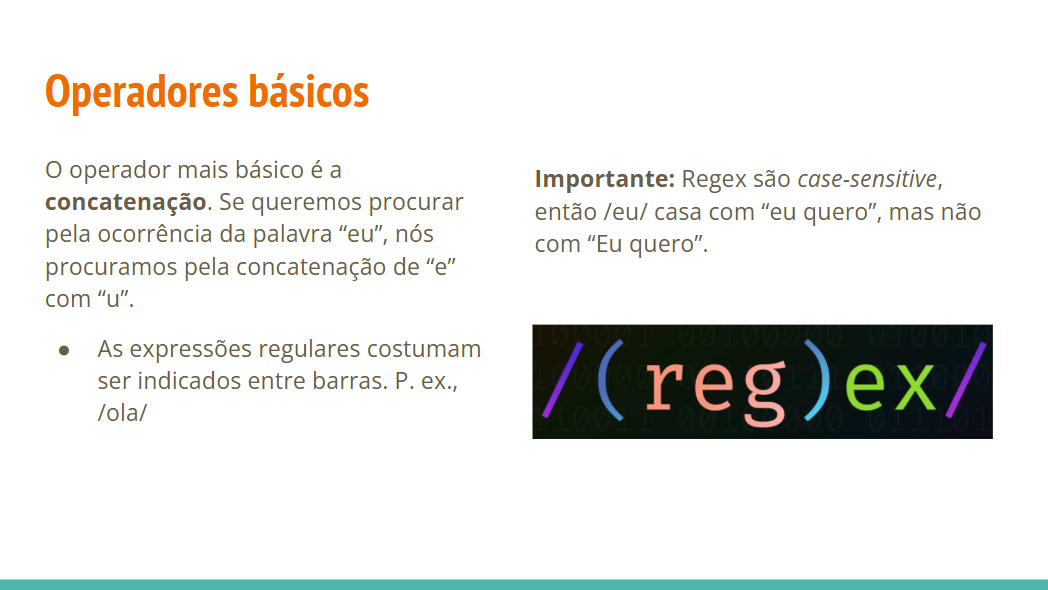

In [5]:
texto = "eu gosto de estudar, mas eu também gosto de descansar."
padrao = re.search('eu', texto)

print(padrao)        # Mostra o objeto Match, com informações sobre onde o padrão foi encontrado
print(padrao.group()) # Mostra o texto que casou com o padrão (nesse caso, 'eu')

<re.Match object; span=(0, 2), match='eu'>
eu


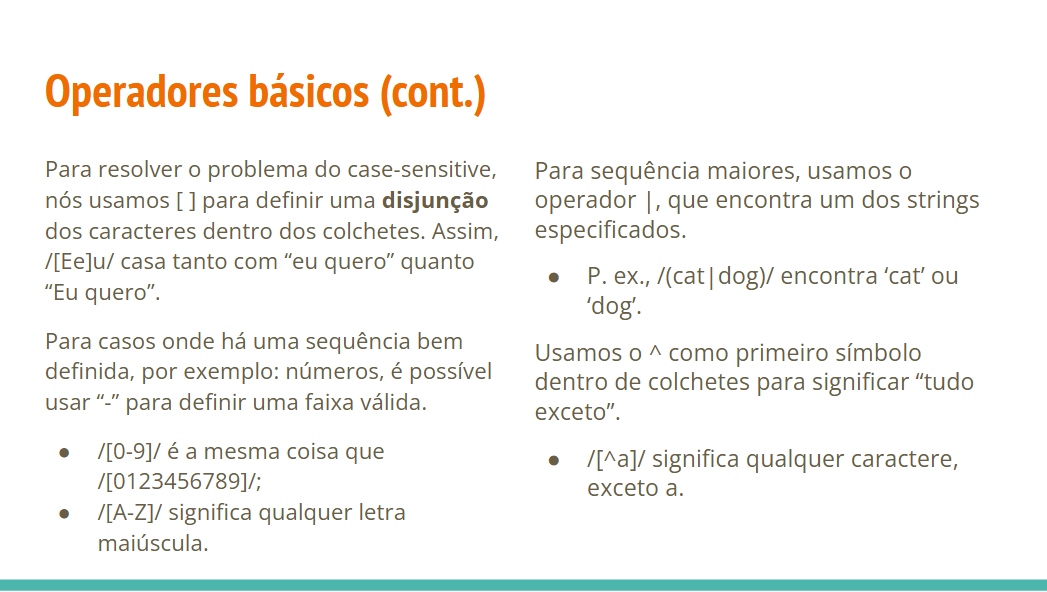

In [6]:
texto = "Eu gosto de estudar, mas eu também gosto de descansar."
padrao = re.compile('[Ee]u')
ocorrencias = padrao.findall(texto)

print(ocorrencias)

['Eu', 'eu']


In [7]:
# Outra opção para abarcar tanto maiúsculas quanto minúsculas
texto = "Eu gosto de estudar, mas eu também gosto de descansar."
padrao = 'eu'
ocorrencias = re.findall(padrao, texto, re.IGNORECASE)

print(ocorrencias)

['Eu', 'eu']


In [8]:
# Para busca em sequências bem definidas
texto = "O produto tem 3 meses e meio de garantia."
padrao = re.compile('[0-9]')
ocorrencias = padrao.findall(texto)

print(ocorrencias)

['3']


In [9]:
# Excluir carcteres
texto = "Uma porção de batata frita"
padrao = '[^Um]'
resultado = re.findall(padrao, texto)

print("Correspondências encontradas:", resultado)

Correspondências encontradas: ['a', ' ', 'p', 'o', 'r', 'ç', 'ã', 'o', ' ', 'd', 'e', ' ', 'b', 'a', 't', 'a', 't', 'a', ' ', 'f', 'r', 'i', 't', 'a']


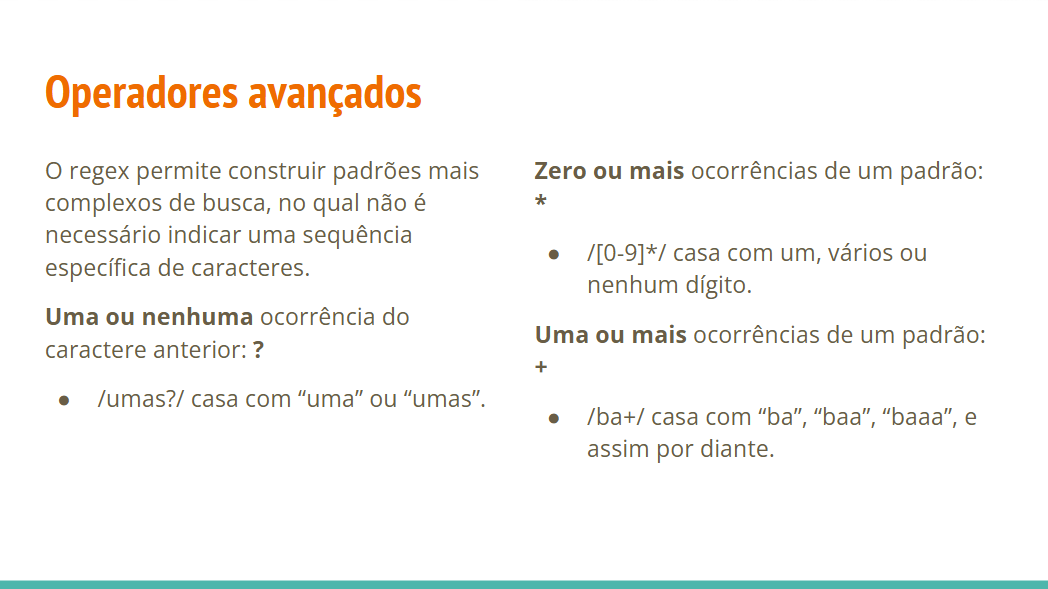

In [10]:
texto = "Eu vi uma casa e umas casas."
padrao = 'umas?'  # "uma" seguido por "s" opcional
resultado = re.findall(padrao, texto)

print("Correspondências encontradas:", resultado)

Correspondências encontradas: ['uma', 'umas']


In [11]:
texto = "Os números são 5, 56, 789 e 0."
padrao = '[0-9][0-9]*'  # Um dígito seguido por zero ou mais dígitos
resultado = re.findall(padrao, texto)

print("Correspondências encontradas:", resultado)

Correspondências encontradas: ['5', '56', '789', '0']


In [12]:
texto = "Eu vi b ba, baa, baaa, e baaaa."
padrao = 'ba+'  # "ba" seguido por um ou mais "a"
resultado = re.findall(padrao, texto)

print("Correspondências encontradas:", resultado)

Correspondências encontradas: ['ba', 'baa', 'baaa', 'baaaa']


**Exemplo**. Suponha um formulário que contém o nome completo de cada pessoa. Como extrair essa informação?

In [13]:
formulario = 'Preencha o formulário de inscrição. Nome: Edson Arantes do Nascimento. Local de Nascimento: Três Corações.'
padrao = 'Nome: ([^.]+)'
# 'Nome:'        → corresponde exatamente ao texto "Nome:" na string
# ' '            → espaço obrigatório logo após "Nome:"
# '([^.]+)'      → grupo de captura:
#                  [^.]+ significa "um ou mais caracteres que NÃO sejam ponto"
#                  O conteúdo capturado será justamente o nome antes do primeiro ponto final.

resultado = re.search(padrao, formulario)

print("Correspondências encontradas:", resultado)

Correspondências encontradas: <re.Match object; span=(36, 69), match='Nome: Edson Arantes do Nascimento'>


O **re.search()** retorna um objeto do tipo Match, que contém informações sobre a primeira correspondência encontrada na string.

Podemos acessar o resultado da busca da seguinte forma:

In [14]:
resultado.group() # ou equivalente: resultado.group(0)

'Nome: Edson Arantes do Nascimento'

A busca captura o string com a correspondência completa, incluindo o trecho do texto que usamos para estabelecer o padrão ('Nome:').

Como extrair o nome? Uma forma seria utilizando o split:


In [15]:
resultado_completo = resultado.group()

resultado_quebrado = resultado_completo.split(': ')
print('Split:', resultado_quebrado)

print('Resposta: ', resultado_quebrado[1])

Split: ['Nome', 'Edson Arantes do Nascimento']
Resposta:  Edson Arantes do Nascimento


Há uma maneira mais fácil de realizar essa extração, que não exige manipular manualmente o texto completo, que é utilizar um grupo de captura.

**Grupos de captura** são subexpressões delimitadas por parênteses () dentro da regex. Eles permitem isolar e extrair partes específicas da correspondência.

Vejamos o exemplo do formulário.

In [16]:
formulario = 'Preencha o formulário de inscrição. Nome: Edson Arantes do Nascimento. Local de Nascimento: Três Corações.'
padrao = 'Nome: ([^.]+)'

resultado = re.search(padrao, formulario).group(1)

print("Resposta:", resultado)

Resposta: Edson Arantes do Nascimento


Para dar outro exemplo, vejamos como extrair as partes de uma data (dia, mês, ano).

In [17]:
# String contendo a data
texto = "Hoje é 08-08-2024."

# Expressão regular com grupos de captura
padrao = r"(\d{2})-(\d{2})-(\d{4})"

# Aplicando a regex para capturar as partes da data
data = re.search(padrao, texto)

if data: # Encontrou o padrão
  dia = data.group(1)  # Primeiro grupo de captura: dia
  mes = data.group(2)  # Segundo grupo de captura: mês
  ano = data.group(3)  # Terceiro grupo de captura: ano
  print(f"Dia: {dia}, Mês: {mes}, Ano: {ano}")
else:
  print("Nenhuma data encontrada.")

Dia: 08, Mês: 08, Ano: 2024


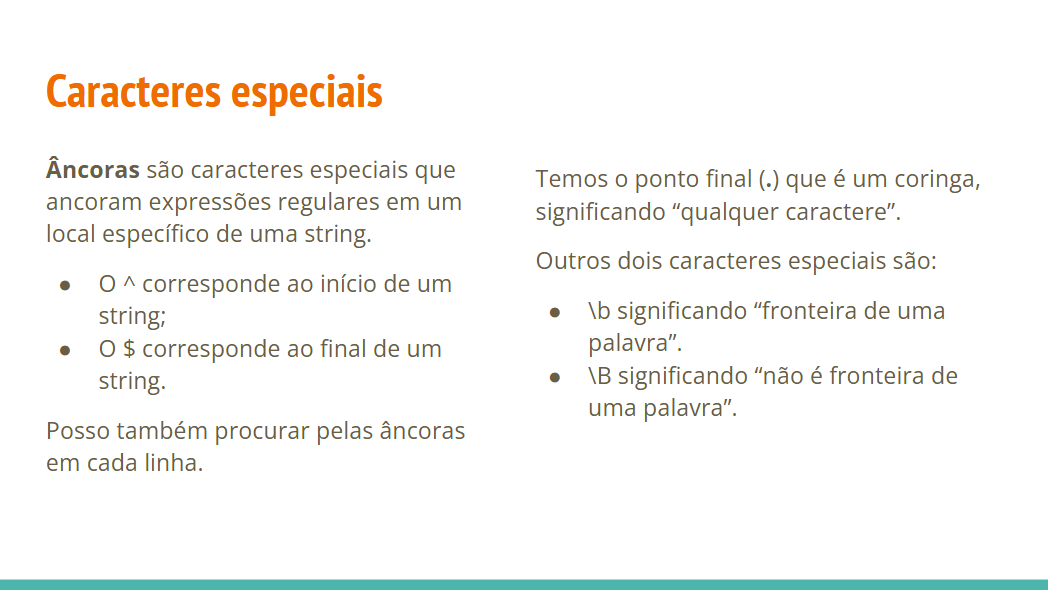

In [18]:
texto = "Python é uma boa linguagem de programação, embora Python nem sempre seja simples"
padrao = '^Python'
resultado = re.findall(padrao, texto)

print("Correspondências encontradas:", resultado)

Correspondências encontradas: ['Python']


In [19]:
texto = "Python é uma boa linguagem de programação simples, embora Python nem sempre seja tão simples"
padrao = 'simples$'
resultado = re.findall(padrao, texto)

print("Correspondências encontradas:", resultado)

Correspondências encontradas: ['simples']


As âncoras referem-se ao string como um todo.

In [20]:
texto = """Início de texto
Esta linha não começa com Início
Início de linha"""

# Regex que procura por "Início" apenas no início da string toda
padrao = '^Início'
resultado = re.findall(padrao, texto)

print("Correspondências encontradas:", resultado)

Correspondências encontradas: ['Início']


In [21]:
texto = """Início de texto
Esta linha não começa com Início
Início de linha"""

# Regex que procura por "Início" em cada linha
padrao = '^Início'
resultado = re.findall(padrao, texto, re.MULTILINE)

print("Correspondências encontradas:", resultado)

Correspondências encontradas: ['Início', 'Início']


In [22]:
texto = "casa casado casamento casa."
padrao = r"\bcasa\b"  # Apenas "casa" isolada
resultado = re.findall(padrao, texto)

print("Correspondências encontradas:", resultado)

Correspondências encontradas: ['casa', 'casa']


In [23]:
texto = "asa casa casado casamento casa."
padrao = r"\Basa"  # 'asa' dentro de palavras, sem estar no início
resultado = re.findall(padrao, texto)

print("Correspondências encontradas:", resultado)

Correspondências encontradas: ['asa', 'asa', 'asa', 'asa']


Outro conjunto de caracteres importantes é aquele relacionado a números e letras.

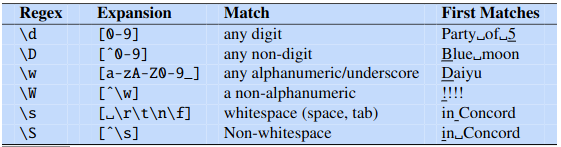

In [24]:
texto = "Distância: 150km. Tempo: 2 horas"
padrao = '\d+'
resultado = re.findall(padrao, texto)

print("Correspondências encontradas:", resultado)

Correspondências encontradas: ['150', '2']


E se eu quiser encontrar um caractere que serve de caracter especial?

In [25]:
texto = 'A operação de adição é realizada com o símbolo de + entre dois números'
padrao = '[a+]'
resultado = re.findall(padrao, texto)

print("Correspondências encontradas:", resultado)

Correspondências encontradas: ['a', 'a', 'a', 'a', 'a', '+']


Como se pode ver, ele interpreta o '+' como significando '1 ou mais elementos' de um padrão; no caso, da letra 'a'.

Para conseguir encontrar um string que inclui o símbolo '+', preciso "escapar" do caractere especial, utilizando a barra invertida.

In [26]:
texto = 'A operação de adição é realizada com o símbolo de + entre dois números'
padrao = '\+'
resultado = re.findall(padrao, texto)

print("Correspondências encontradas:", resultado)

Correspondências encontradas: ['+']


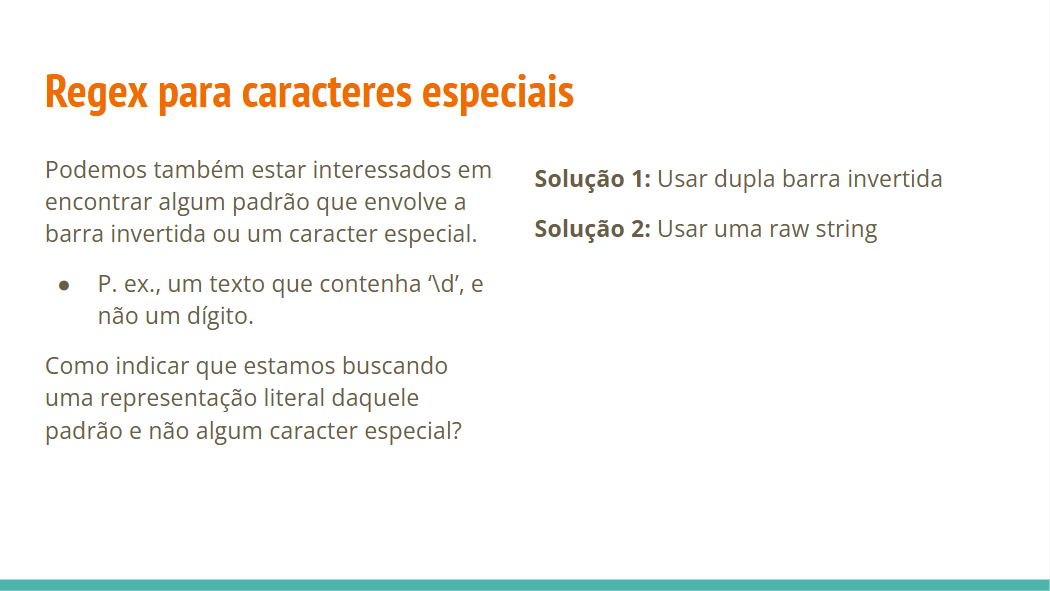

Vamos testar a primeira solução, em que escapamos dos caracteres especiais por meio da barra invertida. Considere o string abaixo:

In [27]:
texto = "O Brasil ganhou 12 medalhas \d nas Olimpíadas."

In [28]:
# Padrão que encontra dígitos
padrao = '\d'
resultado = re.findall(padrao, texto)

print("Correspondências encontradas:", resultado)

Correspondências encontradas: ['1', '2']


In [29]:
# Padrão para encontrar a sequência '\d'
texto = "O Brasil ganhou 12 medalhas \d nas Olimpíadas."
padrao = '\\\d'
resultado = re.findall(padrao, texto)

print("Correspondências encontradas:", resultado)

Correspondências encontradas: ['\\d']


**Observação:** A saída apresenta '//d' porque o print está mostrando a representação da string em Python, e não o texto "cru".

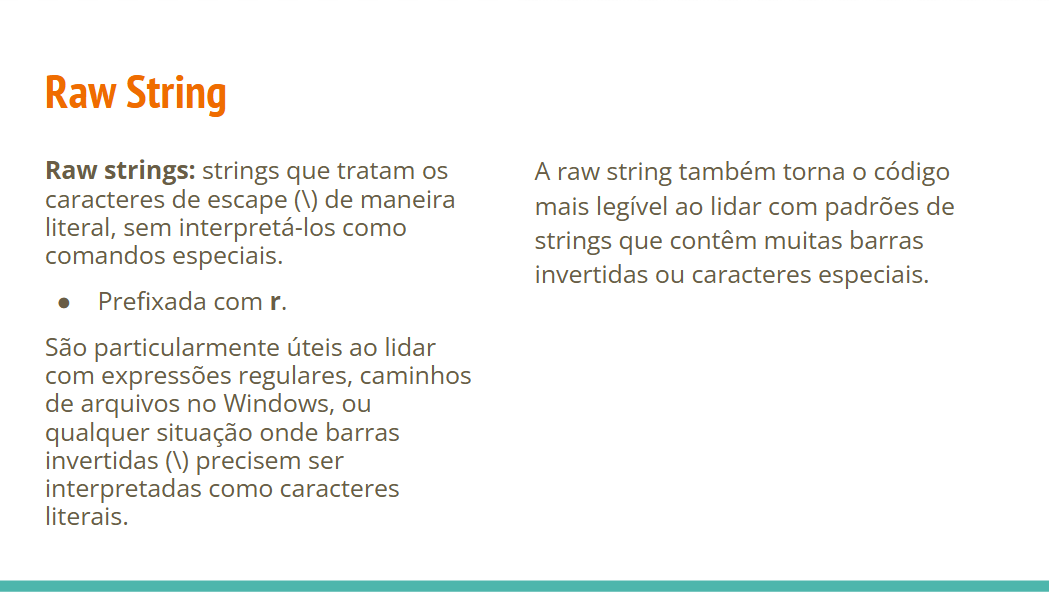

Na raw string, as barras invertidas \ são interpretadas literalmente.

In [30]:
texto_normal = 'Esta é\n uma nova linha\n de python'
print(texto_normal)

texto_raw = r'Esta é\n uma nova linha\n de python'
print(texto_raw)

Esta é
 uma nova linha
 de python
Esta é\n uma nova linha\n de python


Considere novamente o string:

In [31]:
texto = "O Brasil ganhou 12 medalhas \d nas Olimpíadas."

In [32]:
# Padrão que encontra dígitos
padrao = '\d'
resultado = re.findall(padrao, texto)

print("Correspondências encontradas:", resultado)

Correspondências encontradas: ['1', '2']


In [33]:
# Solução com raw string
texto = "O Brasil ganhou 12 medalhas \d nas Olimpíadas."
padrao = r'\\d'
resultado = re.findall(padrao, texto)

print("Correspondências encontradas:", resultado)

Correspondências encontradas: ['\\d']


Veja que usamos duas barras invertidas com o regex e quatro barras sem ele. Isso porque tanto o python quanto o regex interpretam a barra invertida como um caracter especial. Por isso, preciso escapar duas vezes.

### Exercícios

**Exercício 1:** Faça um regex que encontra todas as ocorrências do artigo feminino plural ('as') no texto abaixo --- incluindo a ocorrência que está entre aspas.

In [34]:
texto = '''Quero encontrar as ocorrências de "as". O artigo feminino no plural.
    Assim, a sequência não pode estar no meio nem nas extremidades das outras palavras.
    As aparências enganam, parece simples, mas pode não ser.'''

print(texto)

Quero encontrar as ocorrências de "as". O artigo feminino no plural.
    Assim, a sequência não pode estar no meio nem nas extremidades das outras palavras.
    As aparências enganam, parece simples, mas pode não ser.


In [35]:
padrao = r'\bas\b'

# re.IGNORECASE para pegar maiúsculas/minúsculas
resultados = re.findall(padrao, texto, flags=re.IGNORECASE)

print(resultados)

['as', 'as', 'As']


**Exercício 2:** Temos um conjunto de descrições de eletrônicos. Encontre produtos que atendam às seguintes características:

1.   Computadores;
2.   Mais que 3 GHz;
3.   Pelo menos 500 GB de armazenamento;
4.   Custem menos de 3 mil reais.

In [36]:
produtos = ["Geladeira/Refrigerador Electrolux 240L Branco RE31 R$ 1.973,06 no Pix",
"Computador I5 3570 3,80 GHz 16gb SSD 240 Windows 10 Pro Wi Fi - BRX R$ 1.019,89 no Pix",
"computador Completo Intel Core i5 2,66GHz 8GB SSD 240GB Microsoft Windows 10 e Office 365 Monitor 19.5\" EasyPC All R$ 1.047,20 no Pix" ,
"Pc Gamer Cpu Ryzen 7 5700x 3,4 ghz, Ssd 1Tb M.2 Nvme,16gb Memória Ram Ddr4, RTX 3060ti 8gb, Windows 11 Pro - Tech Power Shop R$ 14.550,00 no Pix",
"Geladeira Brastemp Frost Free Duplex 375L Inox - Compartimento Extrafrio Fresh Zone BRM44HK R$ 3.289,06 no Pix",
"Computador Dell Optiplex 3050 I7 7 3.80 GHz 8GB DDR4 SSD 680GB R$ 2.470,95 no Pix "]

In [37]:
# Função para verificar se o produto atende aos critérios
def filtrar_produtos(produtos):
    produtos_filtrados = []

    for produto in produtos:

        # Verifica se é um computador
        if re.search('([Cc]omputador|Gamer)', produto):

            # Verifica a frequência do processador (mais que 3 GHz)
            freq_match = re.search('(\d+[,.]\d+)\s*(GHz|ghz)', produto)
            if freq_match and float(freq_match.group(1).replace(',', '.')) > 3:

              # Verifica o armazenamento (pelo menos 500 GB)
              storage_match = re.search('SSD\s*(\d+)\s*(GB|Tb)', produto, re.IGNORECASE)
              if storage_match:
                tamanho = int(storage_match.group(1))
                unidade = storage_match.group(2)
                # Converte TB para GB
                if unidade == 'Tb':
                  tamanho *= 1000
                # Seleciona apenas os computadores com mais de 500GB
                if tamanho >= 500:

                  # Verifica o preço (menos de 3 mil reais)
                  preco_match = re.search('R\$\s*([\d\.,]+)', produto)
                  if preco_match:
                        preco = float(preco_match.group(1).replace('.', '').replace(',', '.'))
                        if preco < 3000:
                            produtos_filtrados.append(produto)

    return produtos_filtrados

# Filtrar os produtos que atendem aos critérios
produtos_selecionados = filtrar_produtos(produtos)

print(produtos_selecionados)

['Computador Dell Optiplex 3050 I7 7 3.80 GHz 8GB DDR4 SSD 680GB R$ 2.470,95 no Pix ']


### ELIZA

Agora, vamos construir nossa própria versão do chatbot ELIZA. Seu programa deve fazer as seguintes coisas:

* Responder a uma saudação inicial;
* Responder às afirmações do paciente com uma pergunta que utilize os sentimentos expresso por ele. Por exemplo: se o paciente diz "eu me sinto triste", o programa responde "Sinto muito que você esteja triste. O que te deixa triste?". Faça isso para vários sentimentos (alegria, raiva, desânimo, etc.). Tente usar mais de um padrão possível.
* Ao final de 3 perguntas, informe que a consulta terminou.

Veja um exemplo de diálogo do chatbot que eu construí.

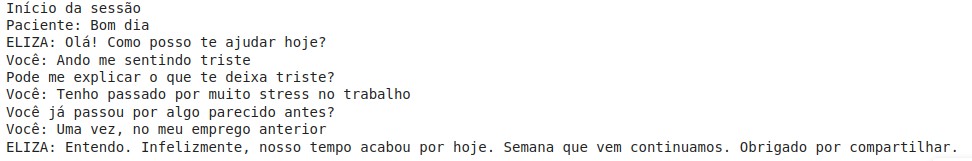

In [42]:
 #aaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaaDicionário de sentimentos e respostas possíveis
respostas_sentimentos = {
    "triste": [
        "Sinto muito que você esteja triste. O que te deixa assim?",
        "Tristeza pode ser difícil. Quer me contar mais sobre isso?"
    ],
    "alegre": [
        "Que bom que você está alegre! O que te deixa tão feliz?",
        "Alegria é contagiante! O que aconteceu de bom?"
    ],
    "raiva": [
        "Raiva pode ser um sentimento intenso. O que causou isso?",
        "Entendo que você esteja com raiva. Quer falar sobre o motivo?"
    ],
    "desânimo": [
        "O desânimo pode ser pesado. O que está acontecendo?",
        "Entendo que você esteja desanimado. Por que acha que está se sentindo assim?"
    ]
}

# Saudação inicial
print("ELIZA: Olá, eu sou a ELIZA. Como você está se sentindo hoje?")

# Contador de interações
for i in range(3):
    entrada = input("Você: ").lower()

    encontrado = False
    for sentimento in respostas_sentimentos:
        # Busca sentimento na frase usando regex para evitar pegar dentro de outras palavras
        if re.search(rf'\b{sentimento}\b', entrada):
            resposta = random.choice(respostas_sentimentos[sentimento])
            print(f"ELIZA: {resposta}")
            encontrado = True
            break

    if not encontrado:
        print("ELIZA: Entendo... pode me explicar melhor como se sente?")

print("ELIZA: Nossa consulta terminou por hoje. Até a próxima!")

ELIZA: Olá, eu sou a ELIZA. Como você está se sentindo hoje?
Você: olá e ELIZA, estou me sentindo alegre hoje, tive bom rendimentos no trabalho e nas minhas atividades do dia
ELIZA: Alegria é contagiante! O que aconteceu de bom?
Você: consegui entregar meus projetos e atividades
ELIZA: Entendo... pode me explicar melhor como se sente?
Você: feliz
ELIZA: Entendo... pode me explicar melhor como se sente?
ELIZA: Nossa consulta terminou por hoje. Até a próxima!


## Extras

Uma boa introdução ao regex pode ser encontrada no livro *Speech and Language Processing*, capítulo 2. Disponível em:
https://web.stanford.edu/~jurafsky/slp3/2.pdf

Vocês podem encontrar mais informações na documentação oficial (https://docs.python.org/3/library/re.html) e nos vários tutoriais disponíveis na internet. Regex nem sempre é fácil de usar, mas existem muitos recursos disponíveis na internet.

Outro recurso interessante é o site https://regex101.com/. Nesse site, vocês podem testar os efeitos de diferentes padrões de busca e encontrar explicações do que está acontecendo.

### Exercícios extras

**Verificação de formato de e-mail**

Escreva uma função que valide se uma string é um e-mail válido. Um e-mail válido deve seguir o formato nome@dominio.com, onde:

* `nome` pode conter letras, números, pontos, hífens e sublinhados.
* `dominio` deve conter apenas letras e números.
* A extensão (após o ponto) deve conter de 2 a 4 letras.

In [39]:
email = "exemplo@dominio.com"
print(validar_email(email))  # Saída esperada: True

email = "exemplo@dominio.c"
print(validar_email(email))  # Saída esperada: False

NameError: name 'validar_email' is not defined

**Extração de datas**

Escreva uma função que extraia todas as datas de um texto. As datas estarão no formato DD/MM/AAAA.

In [ ]:
texto = "Os eventos ocorreram em 12/05/2023, 14/06/2024 e 01/01/2025."
print(extrair_datas(texto))  # Saída esperada: ['12/05/2023', '14/06/2024', '01/01/2025']

**Validação de CEP**

Escreva uma função que valide se um CEP está no formato correto. Um CEP válido deve estar no formato XXXXX-XXX, onde X é um dígito.

In [ ]:
cep = "12345-678"
print(validar_cep(cep))  # Saída esperada: True

cep = "1234-678"
print(validar_cep(cep))  # Saída esperada: False

**Extração de hashtags**

Escreva uma função que extraia todas as hashtags de uma string. Uma hashtag é definida por uma palavra iniciada pelo símbolo #, seguida de letras, números ou sublinhados, sem espaços.

In [ ]:
texto = "Estou aprendendo #Python e #Machine_Learning!"
print(extrair_hashtags(texto))  # Saída esperada: ['#Python', '#Machine_Learning']